(ch:data-visualization)=
# 데이터 시각화

펭귄 데이터셋을 활용하여 기술통계와 선형 상관관계 장에서 사용된 시각화 도구를 종합적으로 소개한다.

**기본 설정**

탐색적 데이터 분석(EDA)에 필요한 핵심 라이브러리를 불러온다.

- `numpy`: 수치 연산
- `pandas`: 데이터프레임 기반 데이터 처리
- `matplotlib.pyplot`: 기본 시각화
- `seaborn`: 통계 시각화 및 펭귄 데이터셋 제공

In [240]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [241]:
pd.set_option('display.precision', 6)

## 펭귄 데이터셋

펭귄 데이터셋은 남극 팔머 군도(Palmer Archipelago)의 세 섬에서 관찰된 세 종(species)의 펭귄 344마리에 대한 측정값을 담고 있으며,
`seaborn` 라이브러리에서 기본 제공한다.

| 특성 | 의미 |
| :--- | :--- |
| `species` | 펭귄 종 (Adelie, Chinstrap, Gentoo) |
| `island` | 관찰된 섬 (Torgersen, Biscoe, Dream) |
| `bill_length_mm` | 부리 길이 (mm) |
| `bill_depth_mm` | 부리 두께 (mm) |
| `flipper_length_mm` | 날개 길이 (mm) |
| `body_mass_g` | 몸무게 (g) |
| `sex` | 성별 (Male, Female) |

In [242]:
penguins = sns.load_dataset('penguins')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


데이터프레임의 기본 정보를 확인한다.
수치형 특성 4개와 범주형 특성 3개로 구성되어 있으며, 일부 특성에 결측치가 존재한다.

In [243]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


결측치를 포함한 행을 제거하여 분석에 사용한다.

In [244]:
penguins = penguins.dropna()
penguins.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 26.7 KB


종별 펭귄 수를 확인한다.

In [245]:
penguins['species'].value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

## 그래프 그리는 세 가지 방식

파이썬으로 그래프를 그리는 방식은 크게 세 가지로 나뉜다.
이 장에서는 세 방식을 모두 사용하므로, 코드를 읽을 때 어떤 방식이 사용되었는지 구분할 수 있어야 한다.

**방식 1: `matplotlib.pyplot` 함수 직접 호출**

`matplotlib.pyplot` 모듈(보통 `plt`로 불러옴)이 제공하는 함수를 직접 호출하는 방식이다.
데이터를 어레이나 시리즈 형태로 함수에 전달한다.

- 히스토그램: `plt.hist(데이터, ...)`
- 산점도: `plt.scatter(x, y, ...)`
- 그래프 객체에 접근: `ax.hist(...)`, `ax.scatter(...)`

**방식 2: 판다스 데이터프레임/시리즈 메서드**

판다스가 내부적으로 `matplotlib`을 호출하여 그래프를 그려 주는 메서드를 사용한다.
데이터프레임이나 시리즈에서 직접 메서드를 호출하면 되므로 코드가 짧고 직관적이다.

- 히스토그램: `시리즈.hist(...)` 또는 `데이터프레임.hist(...)`
- 상자 그림: `데이터프레임.boxplot(...)`
- 산점도: `데이터프레임.plot.scatter(x=..., y=...)`

**방식 3: `seaborn` 라이브러리 활용**

통계 시각화에 특화된 `seaborn` 라이브러리(보통 `sns`로 불러옴)는 내부적으로 `matplotlib`을 사용하지만,
더 정돈된 모양과 통계적 기능(회귀선, 분포 추정 등)을 기본으로 제공한다.
데이터프레임을 통째로 받아 `x`, `y`, `hue` 등의 인자로 그래프를 지정한다.

- 히스토그램: `sns.histplot(data=..., x=..., hue=...)`
- 산점도: `sns.scatterplot(data=..., x=..., y=..., hue=...)`
- 산점도 + 회귀선: `sns.regplot(...)`, `sns.lmplot(...)`
- 히트맵: `sns.heatmap(...)`

세 방식 모두 결국 `matplotlib`을 거쳐 그래프가 그려지므로, `plt.xlabel()`, `plt.title()`, `plt.show()`와 같은
꾸미기 함수는 어느 방식과도 함께 사용할 수 있다.

### 방식 비교: 동일한 히스토그램

동일한 히스토그램을 두 방식으로 그려서 결과를 비교한다.
두 그래프의 형태는 동일하지만 호출하는 코드가 다르다.

**방식 1: `plt.hist()` 직접 호출**

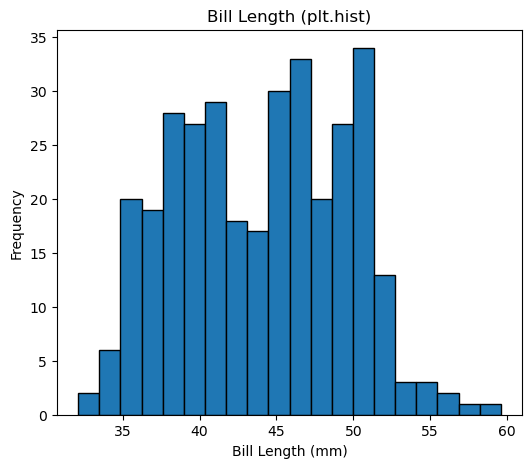

In [246]:
plt.hist(penguins['bill_length_mm'], bins=20, edgecolor='black')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Frequency')
plt.title('Bill Length (plt.hist)')
plt.show()

**방식 2: 시리즈의 `hist()` 메서드**

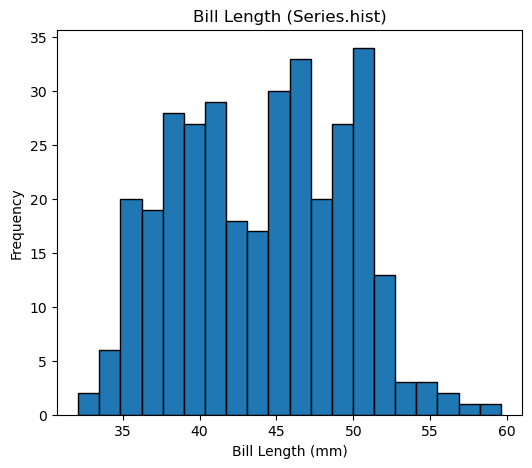

In [247]:
penguins['bill_length_mm'].hist(bins=20, edgecolor='black', grid=False)
plt.xlabel('Bill Length (mm)')
plt.ylabel('Frequency')
plt.title('Bill Length (Series.hist)')
plt.show()

방식 2에서도 `plt.xlabel()`, `plt.title()`, `plt.show()`와 같은 `pyplot` 함수를 함께 사용해
축 이름과 제목 등을 지정한다.
즉, **그래프를 어떻게 그릴지 결정하는 부분**(데이터프레임 메서드 vs `pyplot` 함수)만 다를 뿐,
**그래프 꾸미기 부분**은 두 방식 모두 `matplotlib.pyplot`을 사용한다.

**방식 3: `seaborn`의 `histplot()` 함수**

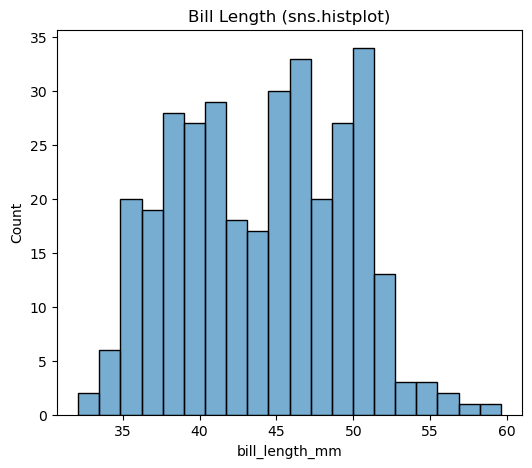

In [248]:
sns.histplot(data=penguins, x='bill_length_mm', bins=20, alpha=0.6)
plt.title('Bill Length (sns.histplot)')
plt.show()

방식 3은 데이터프레임을 통째로 전달하고 컬럼 이름만 지정하면 되므로 코드가 매우 짧다.
또한 막대의 색·투명도 등 시각적 표현이 기본적으로 정돈되어 있어, 보고서나 발표용 그래프에 적합하다.

### 방식 비교: 동일한 산점도

산점도도 마찬가지로 두 방식으로 그릴 수 있다.

**방식 1: `plt.scatter()` 직접 호출**

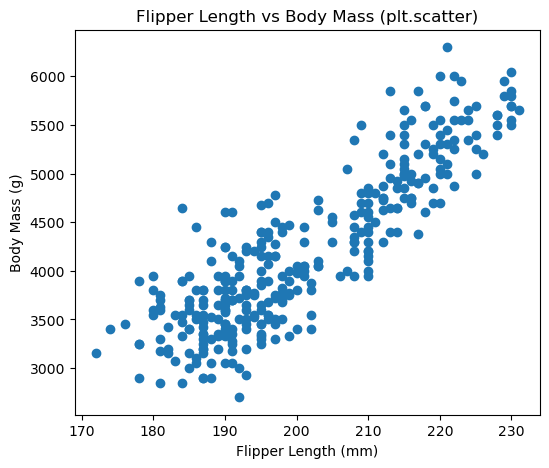

In [249]:
plt.scatter(penguins['flipper_length_mm'], penguins['body_mass_g'])
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.title('Flipper Length vs Body Mass (plt.scatter)')
plt.show()

**방식 2: 데이터프레임의 `plot.scatter()` 메서드**

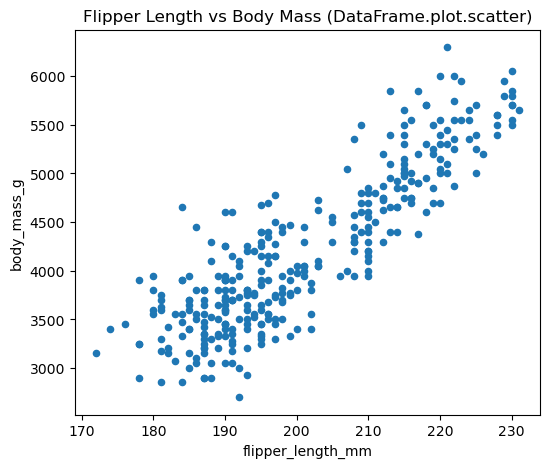

In [250]:
penguins.plot.scatter(x='flipper_length_mm', y='body_mass_g',
                     title='Flipper Length vs Body Mass (DataFrame.plot.scatter)')
plt.show()

**방식 3: `seaborn`의 `scatterplot()` 함수**

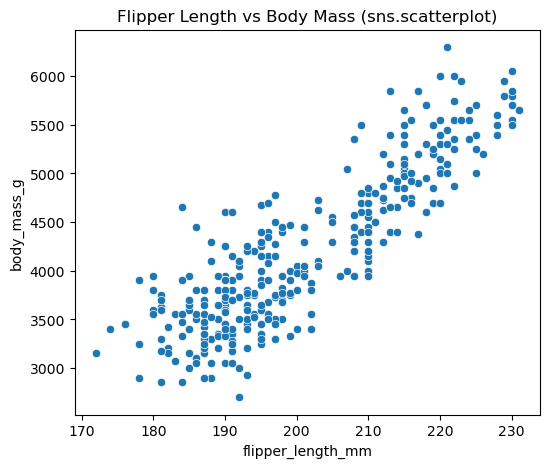

In [251]:
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g')
plt.title('Flipper Length vs Body Mass (sns.scatterplot)')
plt.show()

`seaborn`은 같은 산점도라도 `hue='species'` 인자 한 줄을 추가하면 종별 색상 구분이 자동으로 이뤄진다.
이런 통계적 표현이 손쉽게 가능한 점이 `seaborn`의 가장 큰 장점이다.

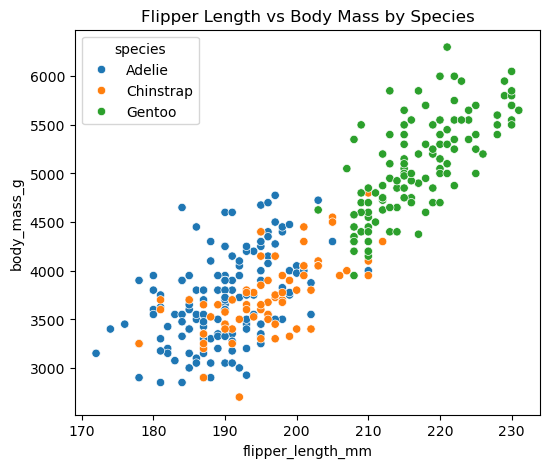

In [252]:
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g', hue='species')
plt.title('Flipper Length vs Body Mass by Species')
plt.show()

**어느 방식을 사용해야 할까?**

- 데이터가 이미 데이터프레임 형태이고 한두 줄로 빠르게 그래프를 그리고 싶다면 **방식 2**가 편리하다.
- 어레이나 리스트 같은 다양한 형태의 데이터를 다루거나, 서브플롯에 그래프를 세밀하게 배치하려면 **방식 1**이 유용하다.
- 종별·그룹별 색상 구분, 회귀선, 분포 추정 등 통계적 표현이 필요하거나 결과물을 보기 좋게 다듬고 싶다면 **방식 3**(`seaborn`)이 가장 적합하다.
- 본 장의 뒷부분(서브플롯 관리)에서는 방식 1을 주로 사용하고, 회귀선·히트맵 등 통계 시각화에서는 방식 3을 사용한다.
  나머지 부분에서는 세 방식을 상황에 맞게 함께 사용한다.

## 1차원 데이터 시각화

한 변수의 분포를 살펴보는 그래프로 **히스토그램**과 **상자 그림**을 사용한다.

### 히스토그램

**히스토그램**<font size='2'>histogram</font>은 데이터를 일정한 구간(bin)으로 나누어 각 구간에 속하는 값의 빈도를 막대로 표현한다.
데이터의 전체적인 분포를 한눈에 파악할 수 있다.
아래 코드는 펭귄의 부리 길이 분포를 히스토그램으로 그린다.

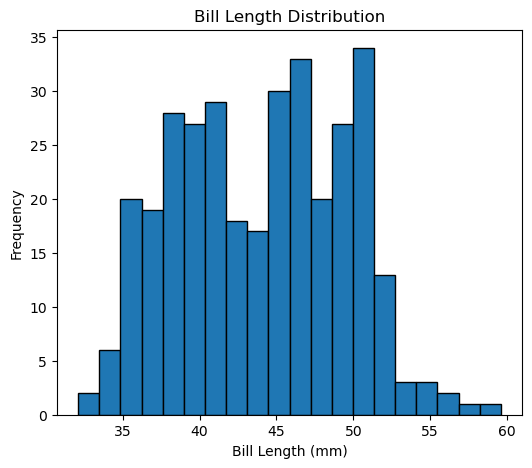

In [253]:
penguins['bill_length_mm'].hist(bins=20, edgecolor='black', grid=False)

plt.xlabel('Bill Length (mm)')
plt.ylabel('Frequency')
plt.title('Bill Length Distribution')
plt.show()

구간 개수를 그대로 지정하는 대신 데이터 범위에 맞춰 일정한 폭의 구간을 직접 설정할 수 있다.

**방식 1: `plt.hist()` 함수 직접 호출**

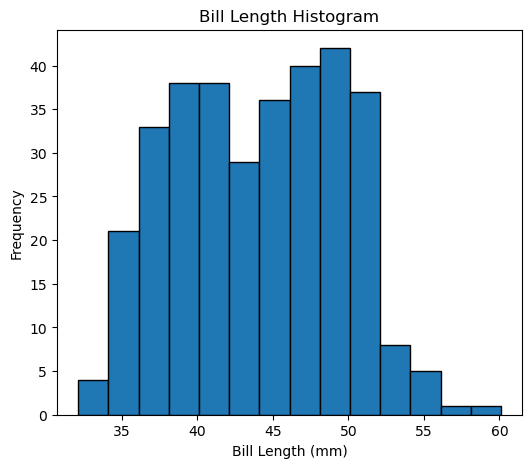

In [254]:
bl = penguins['bill_length_mm']
bins = np.arange(bl.min(), bl.max() + 2, 2)

plt.hist(bl, bins=bins, edgecolor='black')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Frequency')
plt.title('Bill Length Histogram')
plt.show()

`seaborn` 라이브러리의 `histplot()` 함수는 보다 정돈된 형태의 히스토그램을 그린다.

**방식 3: `seaborn`의 `histplot()` 함수**

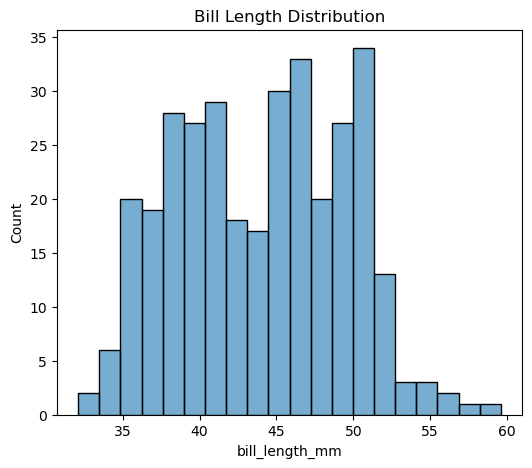

In [255]:
sns.histplot(data=penguins, x='bill_length_mm', bins=20, alpha=0.6)

plt.title('Bill Length Distribution')
plt.show()

**종별 히스토그램**

`hue` 인자를 사용하면 종(species)별로 색을 달리하여 동일한 그래프 위에 겹쳐 그릴 수 있다.
이렇게 하면 종에 따라 부리 길이의 분포가 어떻게 다른지 한눈에 비교할 수 있다.

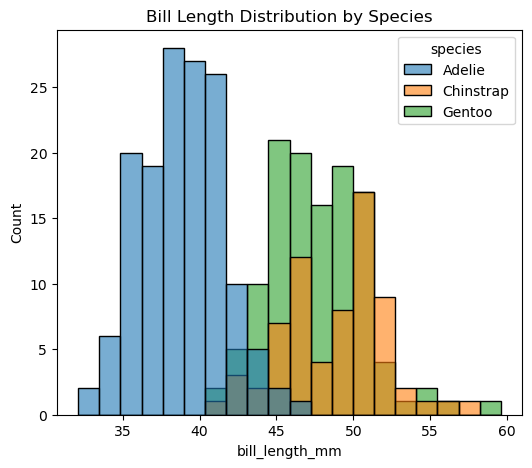

In [256]:
sns.histplot(data=penguins, x='bill_length_mm', hue='species', bins=20, alpha=0.6)

plt.title('Bill Length Distribution by Species')
plt.show()

### 상자 그림

**상자 그림**<font size='2'>box plot</font>은 사분위수, 중앙값, 이상치를 시각적으로 표현하여 데이터의 퍼짐 정도와 이상치를 한눈에 파악할 수 있게 해준다.
아래 코드는 펭귄의 몸무게(`body_mass_g`)에 대한 상자 그림을 그린다.

상자 그림은 주로 데이터프레임의 `boxplot()` 메서드(방식 2)를 사용한다.
여러 특성을 한 번에 그리거나 그룹별로 나누어 그릴 때 편리하다.

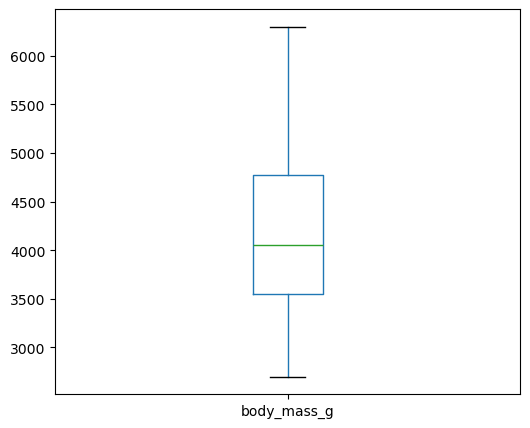

In [257]:
penguins.boxplot(
    column=['body_mass_g'],
    grid=False,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5)
)
plt.show()

**종별 상자 그림**

`by` 인자를 사용하면 종별 그룹으로 나눠 여러 특성의 상자 그림을 한 번에 그릴 수 있다.
`layout=(1, 4)`는 4개의 그래프를 한 행으로 나란히 배치한다.

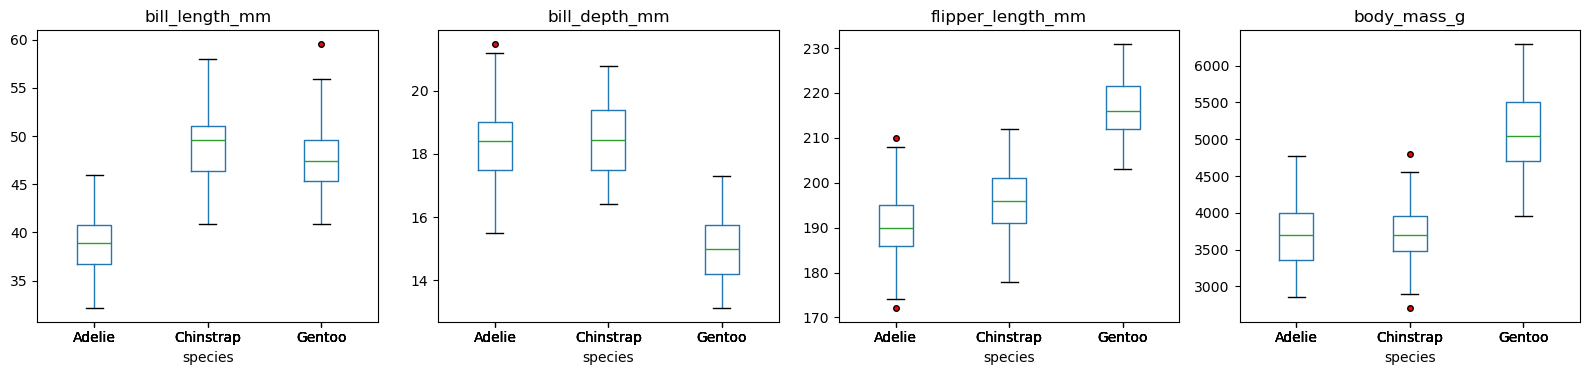

In [258]:
penguins.boxplot(
    column=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'],
    by='species',
    layout=(1, 4),
    figsize=(16, 4),
    grid=False,
    sharey=False,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=4)
)
plt.suptitle('')
plt.tight_layout()
plt.show()

## 2차원 데이터 시각화

두 변수 사이의 관계를 살펴보는 데에는 **산점도**가 가장 기본이며,
여기에 **회귀선**, **산점도 행렬**, **상관관계 히트맵**을 더해 다각도로 분석할 수 있다.

### 산점도

**방식 2: 데이터프레임의 `plot.scatter()` 메서드**

데이터프레임의 `plot.scatter()` 메서드를 이용하여 두 특성 사이의 관계를 산점도로 그린다.
아래 그래프는 날개 길이(`flipper_length_mm`)와 몸무게(`body_mass_g`)의 관계를 보여준다.
두 특성 사이에 양의 선형 상관관계가 뚜렷하게 나타난다.

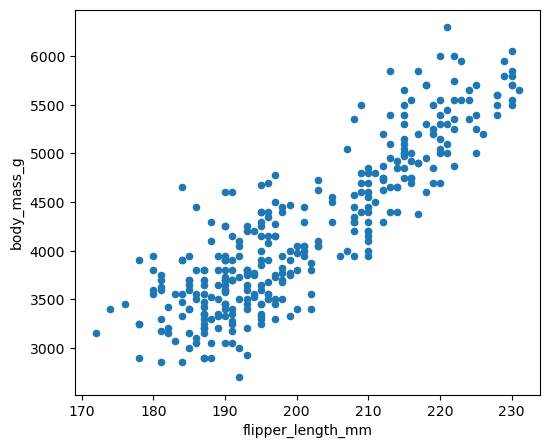

In [259]:
penguins.plot.scatter(x='flipper_length_mm', y='body_mass_g')
plt.show()

**방식 1: `plt.scatter()` 함수 직접 호출**

반면 부리 길이(`bill_length_mm`)와 부리 두께(`bill_depth_mm`)의 관계는 `plt.scatter()`로 그려 본다.
전체적으로 약한 음의 상관관계처럼 보이는데, 이 관계가 정말 음의 상관관계인지는 뒤에서 종별로 나눠 살펴본다.

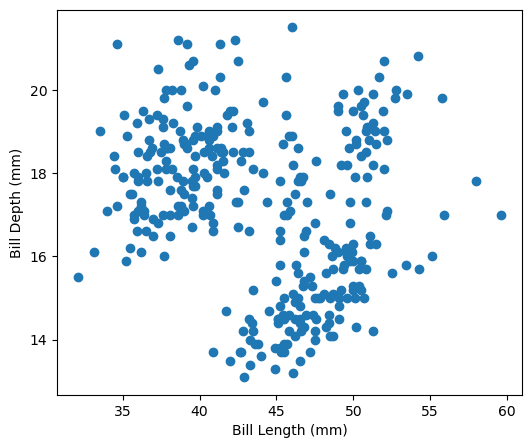

In [260]:
plt.scatter(penguins['bill_length_mm'], penguins['bill_depth_mm'])
plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')
plt.show()

### 회귀선이 포함된 산점도

`seaborn`의 `regplot()` 함수는 산점도와 함께 선형 회귀선을 그려 준다.
이를 이용하면 두 변수 사이의 추세를 시각적으로 확인할 수 있다.

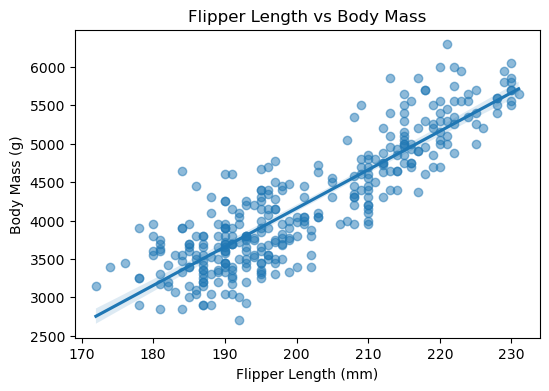

In [261]:
plt.figure(figsize=(6, 4))

sns.regplot(data=penguins,
            x='flipper_length_mm',
            y='body_mass_g',
            scatter_kws={'alpha': 0.5})

plt.title('Flipper Length vs Body Mass')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.show()

**종별 회귀선**

`lmplot()` 함수는 `hue` 인자를 통해 종별로 색상을 달리하여 산점도와 회귀선을 그릴 수 있다.
앞서 부리 길이와 부리 두께의 산점도는 음의 상관관계처럼 보였지만, 종별로 나눠 보면 각 종 안에서는 오히려 **양의 상관관계**가 나타난다.
이는 다음 장에서 자세히 다룰 **심슨의 역설**<font size='2'>Simpson's paradox</font>의 한 예이다.

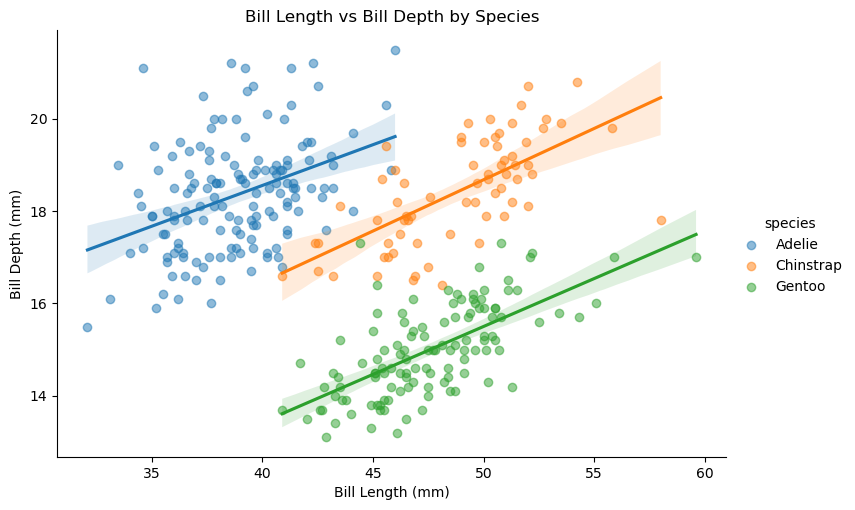

In [262]:
sns.lmplot(data=penguins,
           x='bill_length_mm',
           y='bill_depth_mm',
           hue='species',
           height=5,
           aspect=1.5,
           scatter_kws={'alpha': 0.5})

plt.title('Bill Length vs Bill Depth by Species')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')
plt.show()

### 산점도 행렬

데이터프레임에 포함된 모든 수치형 특성 사이의 관계를 한 번에 보고 싶다면 **산점도 행렬**<font size='2'>scatter matrix</font>을 사용한다.
대각선에는 각 특성의 히스토그램이, 그 외 영역에는 두 특성의 산점도가 표시된다.

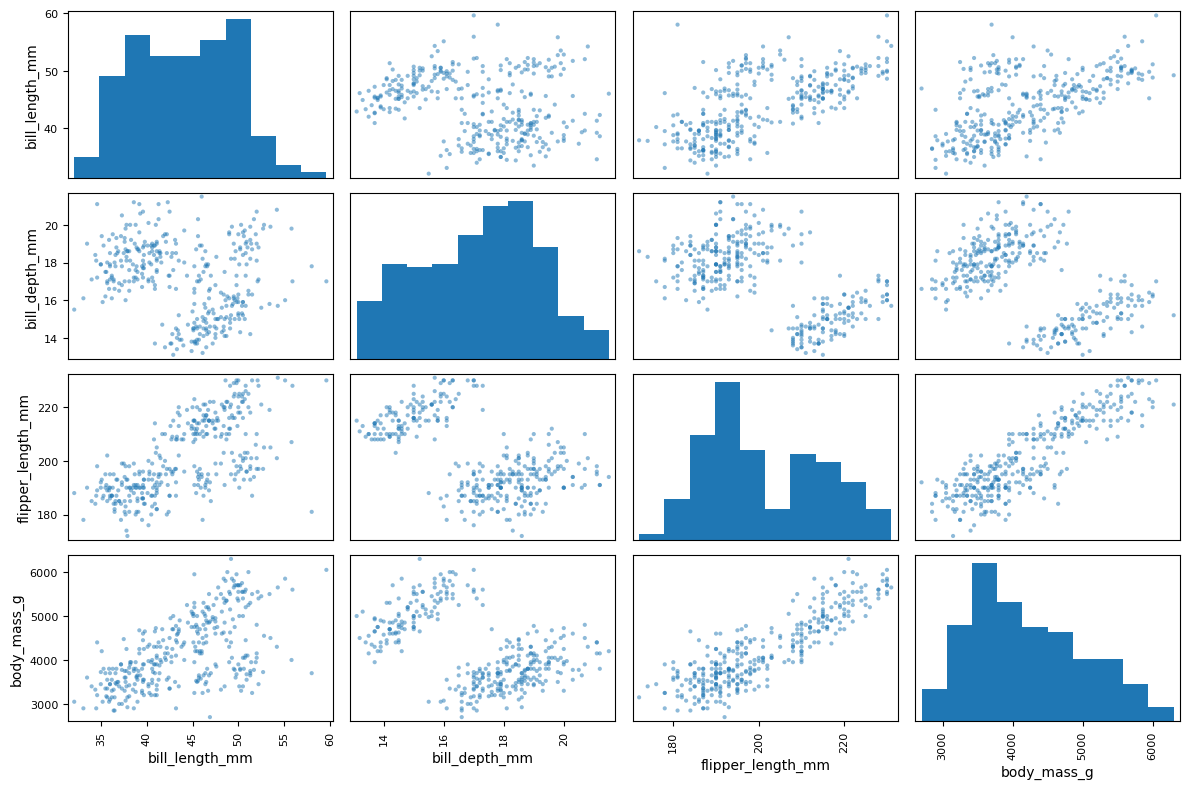

In [263]:
from pandas.plotting import scatter_matrix

axs = scatter_matrix(penguins, figsize=(12, 8))
plt.tight_layout()
plt.show()

### 상관관계 히트맵

**히트맵**<font size='2'>heatmap</font>은 행렬 형태의 값을 색상의 농도로 표현하는 그래프이다.
상관계수 행렬을 히트맵으로 그리면 어떤 특성 쌍이 강한 양 또는 음의 상관관계를 갖는지 한눈에 파악할 수 있다.

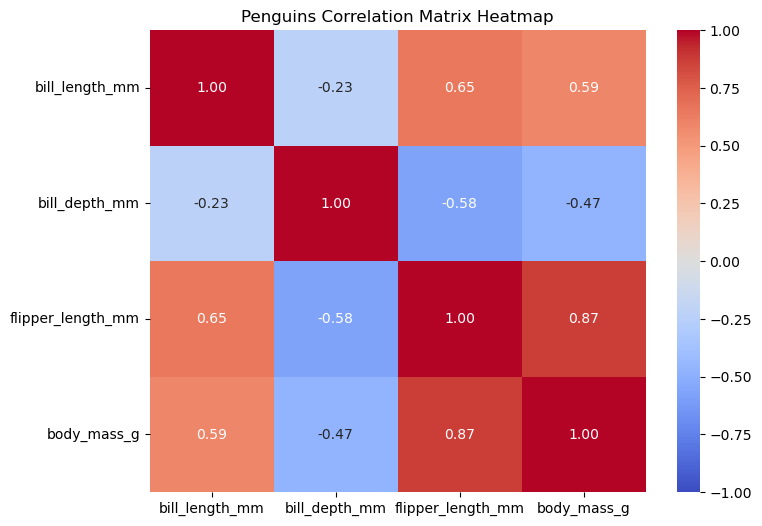

In [264]:
corr_matrix = penguins.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,        # 각 셀에 상관계수 값 표시
            cmap='coolwarm',   # 색상 맵
            fmt='.2f',         # 소수점 둘째 자리까지
            vmin=-1,
            vmax=1)

plt.title('Penguins Correlation Matrix Heatmap')
plt.show()

상관계수 행렬은 대각선을 기준으로 대칭이므로, 위쪽 삼각형 영역을 마스킹하여 아래쪽만 표시하면 더욱 보기 좋다.

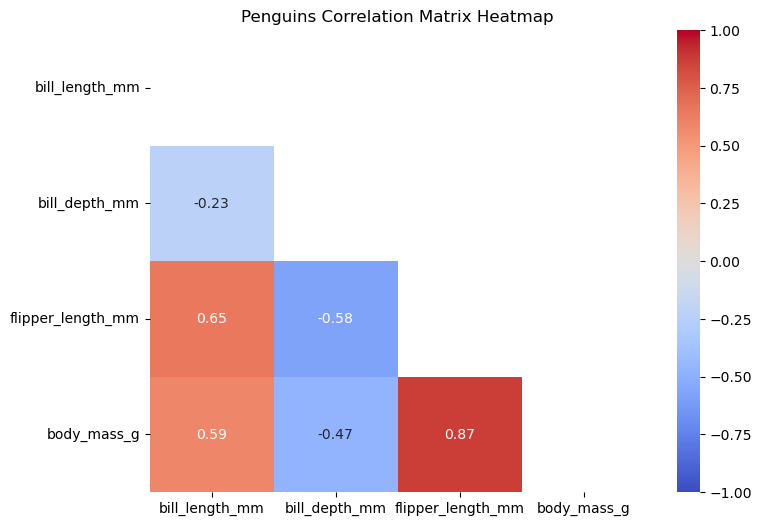

In [265]:
corr_matrix = penguins.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            vmin=-1,
            vmax=1,
            mask=mask)

plt.title('Penguins Correlation Matrix Heatmap')
plt.show()

## 서브플롯 관리

여러 개의 그래프를 원하는 모양과 크기로 한번에 배치하려면 `Figure` 객체와 **서브플롯**<font size='2'>subplot</font>을 활용한다.
`Figure`는 그림 액자, 서브플롯은 그 액자 안에 배치되는 도화지에 해당한다.

**왜 서브플롯에서는 방식 1이 유용한가?**

- 서브플롯의 격자(`Figure`, `Axes`, `add_subplot()`, `plt.subplots()`)는 모두 `matplotlib`의 개념이며,
  방식 1의 `ax.scatter()`, `ax.hist()`처럼 `Axes` 객체에 직접 그리는 흐름과 자연스럽게 맞물린다.
- 방식 2(`df.plot.X()`, `df.boxplot()`)와 방식 3 axes-level 함수도 `ax=` 인자로 격자에 끼워 넣을 수 있지만,
  `ax=`를 빠뜨리면 자기 Figure를 새로 만들어 버려 격자 밖에 그래프가 따로 그려진다.
  또한 `seaborn`의 figure-level 함수(`lmplot`, `pairplot` 등)는 자체 `FacetGrid`를 만들기 때문에 격자 안에 들어가지 않는다.
- 방식 1은 데이터가 어레이·시리즈·리스트 등 어떤 형태든 동일하게 다룰 수 있어,
  여러 그래프를 한 번에 배치할 때 가장 일관되고 유연하다.

이러한 이유로 본 절은 격자(`fig, axes = plt.subplots(...)`) 자체는 방식 1로 만들고,
각 칸 안에서는 세 방식을 상황에 맞게 섞어 쓰는 패턴을 함께 익힌다.

### Figure와 단일 서브플롯

다음 두 코드는 동일한 산점도를 그린다.
첫 번째는 `plt.scatter()`를 직접 호출하는 간단한 방식이고,
두 번째는 `Figure` 객체를 만들어 서브플롯을 추가하는 방식이다.
그래프 하나를 그릴 때는 첫 번째 방식이 간편하지만,
여러 그래프를 한꺼번에 배치하려면 두 번째 방식이 훨씬 유용하다.

**그래프 코드 1**

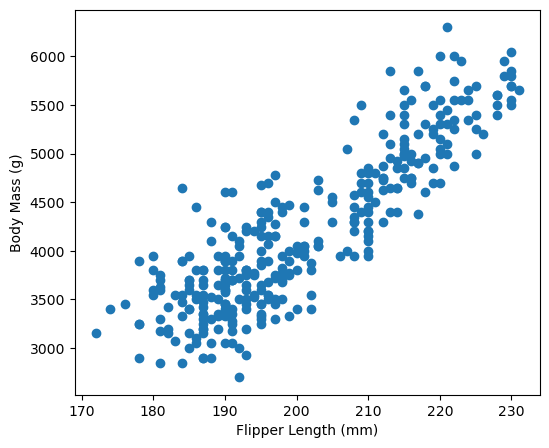

In [266]:
plt.rc('figure', figsize=(6, 5))
plt.scatter(penguins['flipper_length_mm'], penguins['body_mass_g'])

plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.show()

**그래프 코드 2**

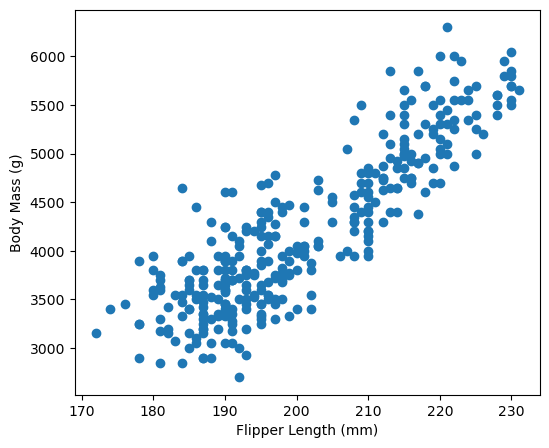

In [267]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1)

ax.scatter(penguins['flipper_length_mm'], penguins['body_mass_g'])
ax.set_xlabel('Flipper Length (mm)')
ax.set_ylabel('Body Mass (g)')

plt.show()

두 그래프 코드의 차이점은 `Figure` 객체와 서브플롯의 활용에 있다.

**`Figure` 객체**

`Figure` 객체는 아래 코드로 생성한다. 생성된 객체는 그림 액자의 기능을 수행한다.

```python
fig = plt.figure(figsize=(6, 5))
```

위 코드에서 `figsize=(6, 5)`는 생성되는 그래프의 크기를 지정한다.
이렇게 하면 앞서 아래 방식으로 지정된 그래프의 크기는 무시된다.

```python
plt.rc('figure', figsize=(6, 5))
```

<p><div align="center"><img src="https://github.com/codingalzi/statsRev/blob/master/jupyter-book/images/figures.png?raw=true" style="width:500px"></div></p>

<p style='text-align:center;'>그림 출처: <a href='https://velog.io/@regista/Matplotlib에서-Figure와-Axes-이해하기-Basic'>Matplotlib에서 Figure와 Axes 이해하기</a></p>

**서브플롯 추가**

서브플롯<font size='2'>subplot</font>은 그래프를 그릴 때 필요한 도화지에 해당한다.
아래 코드는 준비된 `Figure` 객체에 하나의 서브플롯을 추가한다.

```python
ax = fig.add_subplot(1, 1, 1)
```

위 코드는 액자에 한 장의 도화지를 준비한 것과 동일하다.

<p><div align="center"><img src="https://github.com/codingalzi/statsRev/blob/master/jupyter-book/images/figures_subplots.png?raw=true" style="width:600px"></div></p>

<p style='text-align:center;'>그림 출처: <a href='https://velog.io/@regista/Matplotlib에서-Figure와-Axes-이해하기-Basic'>Matplotlib에서 Figure와 Axes 이해하기</a></p>

반면에 아래 코드는 두 개의 서브플롯을 추가한다.

```python
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
```

위 코드는 액자에 두 장의 도화지를 좌우로 배치시키는 효과를 낸다.

<p><div align="center"><img src="https://github.com/codingalzi/statsRev/blob/master/jupyter-book/images/figures_subplots121.png?raw=true" style="width:600px"></div></p>

<p style='text-align:center;'>그림 출처: <a href='https://velog.io/@regista/Matplotlib에서-Figure와-Axes-이해하기-Basic'>Matplotlib에서 Figure와 Axes 이해하기</a></p>

**`add_subplot()` 메서드의 인자**

`add_subplot()` 메서드는 서브플롯을 행렬 모양으로 배치할 때 필요한 세 개의 정보를 인자로 받는다.

- 첫째 인자: 행의 개수
- 둘째 인자: 열의 개수
- 셋째 인자: 생성되는 서브플롯의 인덱스(1부터 시작, 왼쪽 위에서 오른쪽 아래로)

**`Axes` 객체**

`ax1`과 `ax2` 두 변수는 (1, 2) 모양으로 배치된 두 개의 서브플롯 위치 정보를 담은 `Axes` 객체를 가리킨다.

- `ax1`: (1, 2) 모양으로 배치된 두 개의 서브플롯 중에서 첫째, 즉 왼편에 위치한 서브플롯의 위치 정보
- `ax2`: (1, 2) 모양으로 배치된 두 개의 서브플롯 중에서 둘째, 즉 오른편에 위치한 서브플롯의 위치 정보

**그래프 삽입**

특정 서브플롯에 그래프를 그리려면 해당 서브플롯의 위치 정보를 가리키는 `ax1` 또는 `ax2`를 선택하여
`scatter()`, `hist()` 같은 메서드를 호출한다.
예를 들어 `ax1.scatter(x, y)`는 왼쪽 도화지에 산점도를 그리고, `ax2.hist(data)`는 오른쪽 도화지에 히스토그램을 그린다.

또한 `figsize`가 가리키는 값도 눈여겨볼 필요가 있다.
`Figure` 객체 전체의 가로·세로 크기와 비율을 어떻게 지정하느냐에 따라 그래프의 모양이 달라지기 때문이다.

다음 절부터는 펭귄 데이터를 이용해 (1, 2), (2, 1), (2, 2) 등 다양한 격자 배치를 직접 확인한다.

### 좌우 배치: (1, 2)

두 개의 서브플롯을 좌우로 나란히 배치하려면 `add_subplot(1, 2, ...)`를 사용한다.
아래 코드는 부리 길이와 몸무게의 산점도를 좌우로 비교한다.

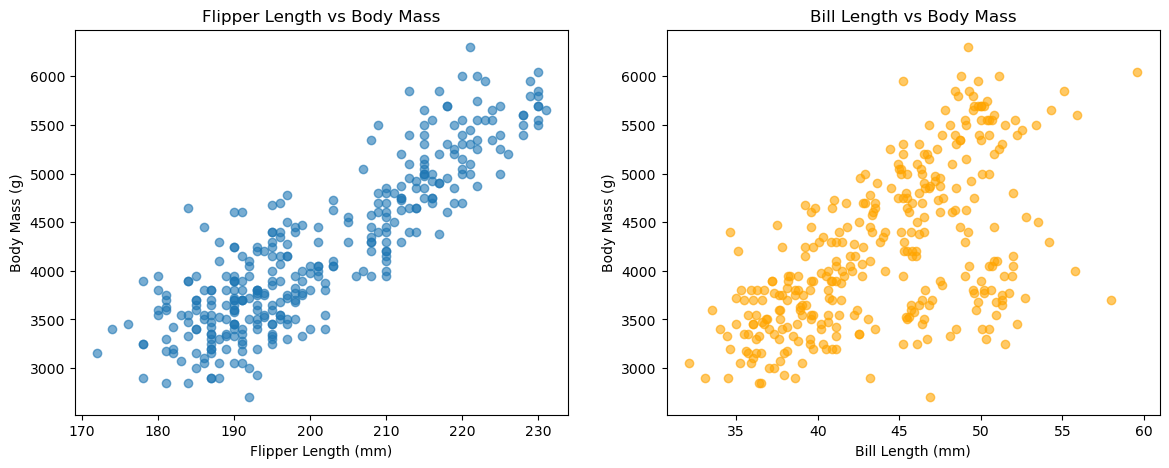

In [268]:
fig = plt.figure(figsize=(14, 5))

# 왼쪽 도화지
ax1 = fig.add_subplot(1, 2, 1)
# 오른쪽 도화지
ax2 = fig.add_subplot(1, 2, 2)

# 왼쪽: 날개 길이 vs 몸무게
ax1.scatter(penguins['flipper_length_mm'], penguins['body_mass_g'], alpha=0.6)
ax1.set_xlabel('Flipper Length (mm)')
ax1.set_ylabel('Body Mass (g)')
ax1.set_title('Flipper Length vs Body Mass')

# 오른쪽: 부리 길이 vs 몸무게
ax2.scatter(penguins['bill_length_mm'], penguins['body_mass_g'], alpha=0.6, color='orange')
ax2.set_xlabel('Bill Length (mm)')
ax2.set_ylabel('Body Mass (g)')
ax2.set_title('Bill Length vs Body Mass')

plt.show()

### 위아래 배치: (2, 1)

두 개의 서브플롯을 위아래로 배치하려면 `add_subplot(2, 1, ...)`을 사용하고,
`figsize`의 둘째 값(높이)을 더 크게 설정해야 비율이 자연스럽다.

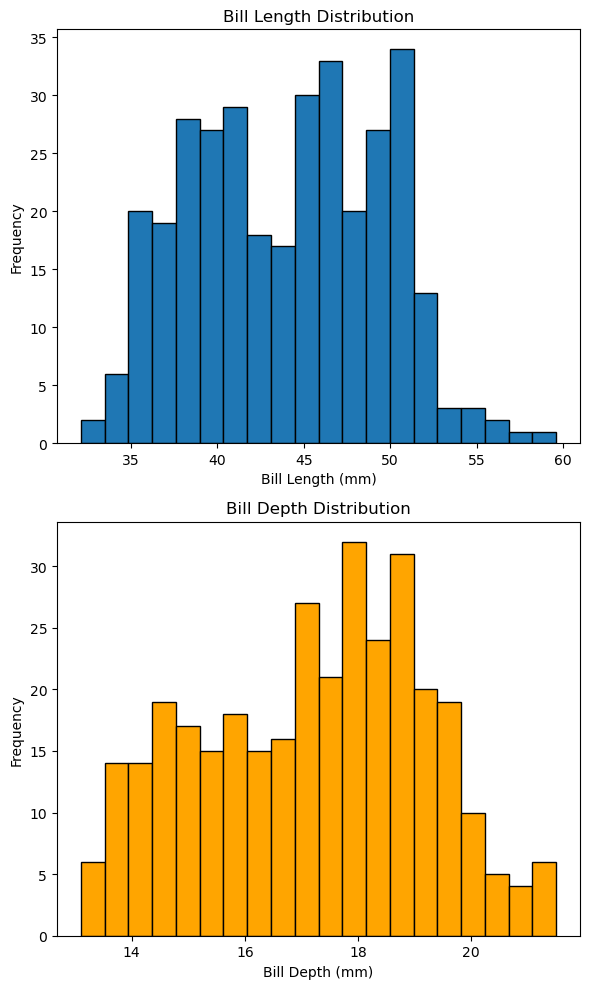

In [269]:
fig = plt.figure(figsize=(6, 10))

# 위쪽 도화지
ax1 = fig.add_subplot(2, 1, 1)
# 아래쪽 도화지
ax2 = fig.add_subplot(2, 1, 2)

ax1.hist(penguins['bill_length_mm'], bins=20, edgecolor='black')
ax1.set_xlabel('Bill Length (mm)')
ax1.set_ylabel('Frequency')
ax1.set_title('Bill Length Distribution')

ax2.hist(penguins['bill_depth_mm'], bins=20, edgecolor='black', color='orange')
ax2.set_xlabel('Bill Depth (mm)')
ax2.set_ylabel('Frequency')
ax2.set_title('Bill Depth Distribution')

plt.tight_layout()
plt.show()

### 격자 배치: (2, 2)

네 개의 수치형 특성에 대한 히스토그램을 (2, 2) 모양의 격자에 배치한다.
각 서브플롯의 인덱스는 1, 2, 3, 4 순서이며,
왼쪽 위 → 오른쪽 위 → 왼쪽 아래 → 오른쪽 아래 순서로 채워진다.

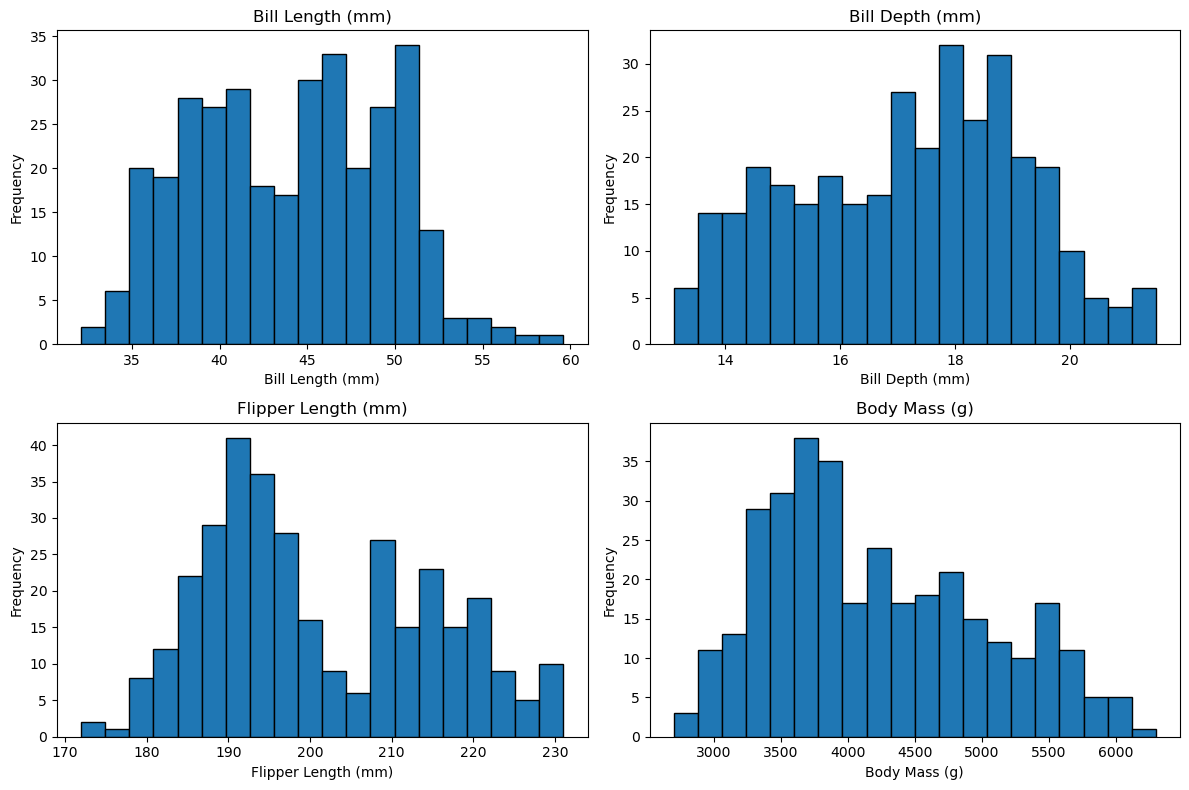

In [270]:
fig = plt.figure(figsize=(12, 8))

features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
titles = ['Bill Length (mm)', 'Bill Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)']

for i, (feat, title) in enumerate(zip(features, titles), start=1):
    ax = fig.add_subplot(2, 2, i)
    ax.hist(penguins[feat], bins=20, edgecolor='black')
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')
    ax.set_title(title)

plt.tight_layout()
plt.show()

### plt.subplots()로 한번에 생성

`plt.subplots()` 함수는 `Figure` 객체와 모든 서브플롯의 `Axes` 객체를 한꺼번에 생성한다.
결과로 반환되는 `axes`는 2차원 배열이며, `axes[i, j]`로 각 위치의 서브플롯에 접근한다.
아래 코드는 종별로 색상을 달리하여 네 가지 산점도를 (2, 2)로 배치한다.

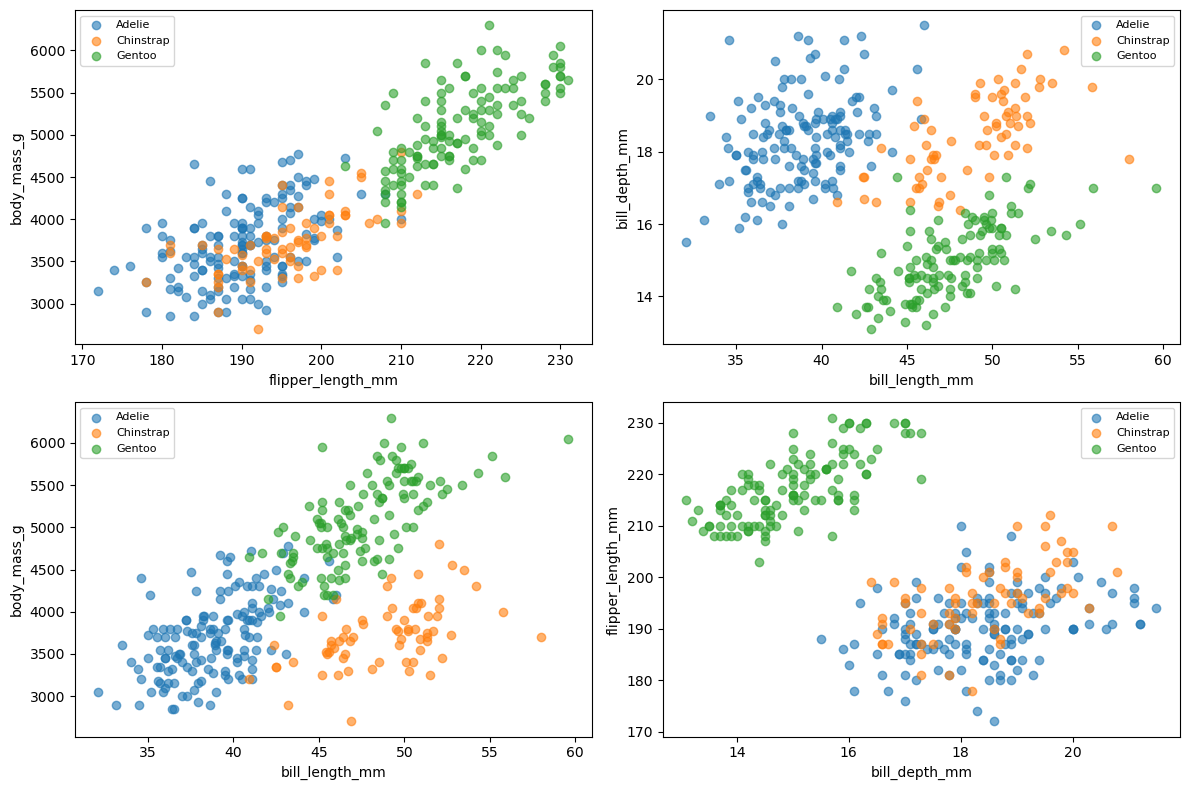

In [271]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

pairs = [
    ('flipper_length_mm', 'body_mass_g'),
    ('bill_length_mm', 'bill_depth_mm'),
    ('bill_length_mm', 'body_mass_g'),
    ('bill_depth_mm', 'flipper_length_mm'),
]
colors = {'Adelie': 'tab:blue', 'Chinstrap': 'tab:orange', 'Gentoo': 'tab:green'}

for ax, (x, y) in zip(axes.flat, pairs):
    for sp, group in penguins.groupby('species'):
        ax.scatter(group[x], group[y], alpha=0.6, label=sp, color=colors[sp])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 세 방식 섞어 쓰기

서브플롯 격자는 `matplotlib`(방식 1)으로 만들고, 각 칸 안에서는 세 방식을 모두 섞어 쓸 수 있다.
방식 2의 `df.plot.X()`/`df.boxplot()`/`series.plot.X()`도 `ax=` 인자를 받고,
방식 3의 axes-level 함수(`sns.histplot`, `sns.scatterplot`, `sns.boxplot`, `sns.regplot` 등)도 `ax=`를 받는다.

:::{warning} `ax=`를 챙길 것
방식 2·3 모두 `ax=`를 빠뜨리면 **자기 Figure를 새로 만들어 버려** 격자 밖에 따로 그래프가 그려진다.
또한 `df.boxplot(by='species', ax=ax)`처럼 그룹화 옵션은 자체적으로 여러 서브플롯을 만들려 해서 `ax=`와 충돌할 수 있다.
그룹별 상자 그림을 한 칸에 그릴 때는 `sns.boxplot(x='species', y='...', ax=ax)`(방식 3)가 더 안전하다.
:::

아래에서 (1, 2)와 (2, 2) 배치 예제를 통해 이 패턴을 익힌다.

**예제 1: (1, 3) — 세 방식으로 같은 격자 채우기**

산점도 한 종류를 세 방식으로 나란히 그려 보면, 각 방식이 어떻게 `ax=`와 결합되는지 한눈에 확인할 수 있다.

- 왼쪽: 방식 1 — `ax.scatter()`
- 가운데: 방식 2 — `df.plot.scatter(..., ax=...)`
- 오른쪽: 방식 3 — `sns.scatterplot(..., ax=...)`

C:\Users\gslee\AppData\Local\Temp\ipykernel_76384\65137177.py:19: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gslee\AppData\Local\Temp\ipykernel_76384\65137177.py:19: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\gslee\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gslee\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


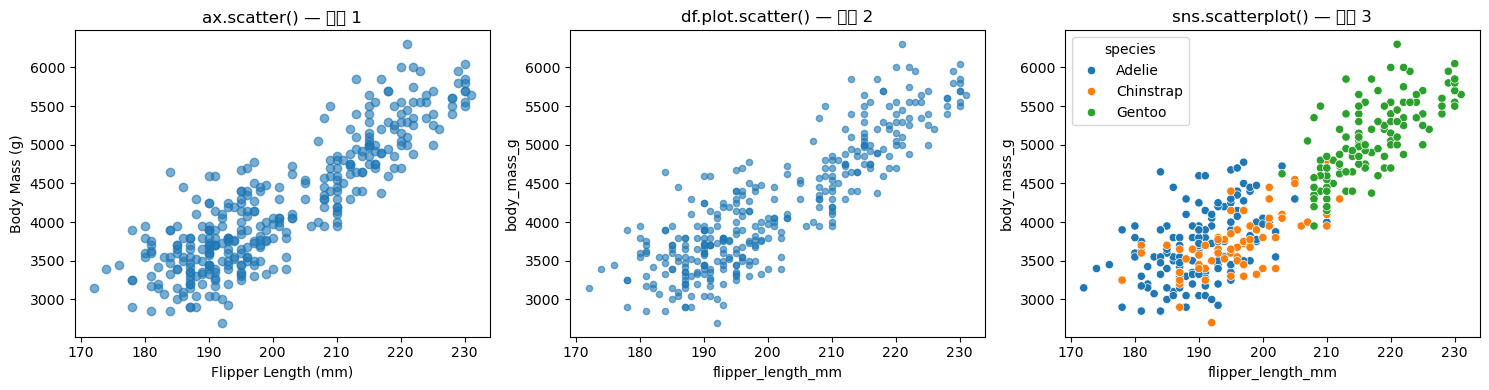

In [272]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 왼쪽: 방식 1
axes[0].scatter(penguins['flipper_length_mm'], penguins['body_mass_g'], alpha=0.6)
axes[0].set_xlabel('Flipper Length (mm)')
axes[0].set_ylabel('Body Mass (g)')
axes[0].set_title('ax.scatter() — 방식 1')

# 가운데: 방식 2
penguins.plot.scatter(x='flipper_length_mm', y='body_mass_g',
                      alpha=0.6, ax=axes[1])
axes[1].set_title('df.plot.scatter() — 방식 2')

# 오른쪽: 방식 3
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g',
                hue='species', ax=axes[2])
axes[2].set_title('sns.scatterplot() — 방식 3')

plt.tight_layout()
plt.show()

**예제 2: (2, 2) — 세 방식을 한 격자에 모두 사용**

한 격자에 산점도, 회귀선, 히스토그램, 상자 그림을 각각 다른 방식으로 그려 본다.

- 좌상단: 방식 1 — `ax.scatter()` (어레이 직접 입력)
- 우상단: 방식 2 — `df.plot.scatter(..., ax=...)` (데이터프레임 메서드)
- 좌하단: 방식 3 — `sns.histplot(..., hue='species', ax=...)` (종별 분포)
- 우하단: 방식 3 — `sns.boxplot(..., ax=...)` (종별 상자 그림)

C:\Users\gslee\AppData\Local\Temp\ipykernel_76384\1160105051.py:24: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gslee\AppData\Local\Temp\ipykernel_76384\1160105051.py:24: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\gslee\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gslee\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


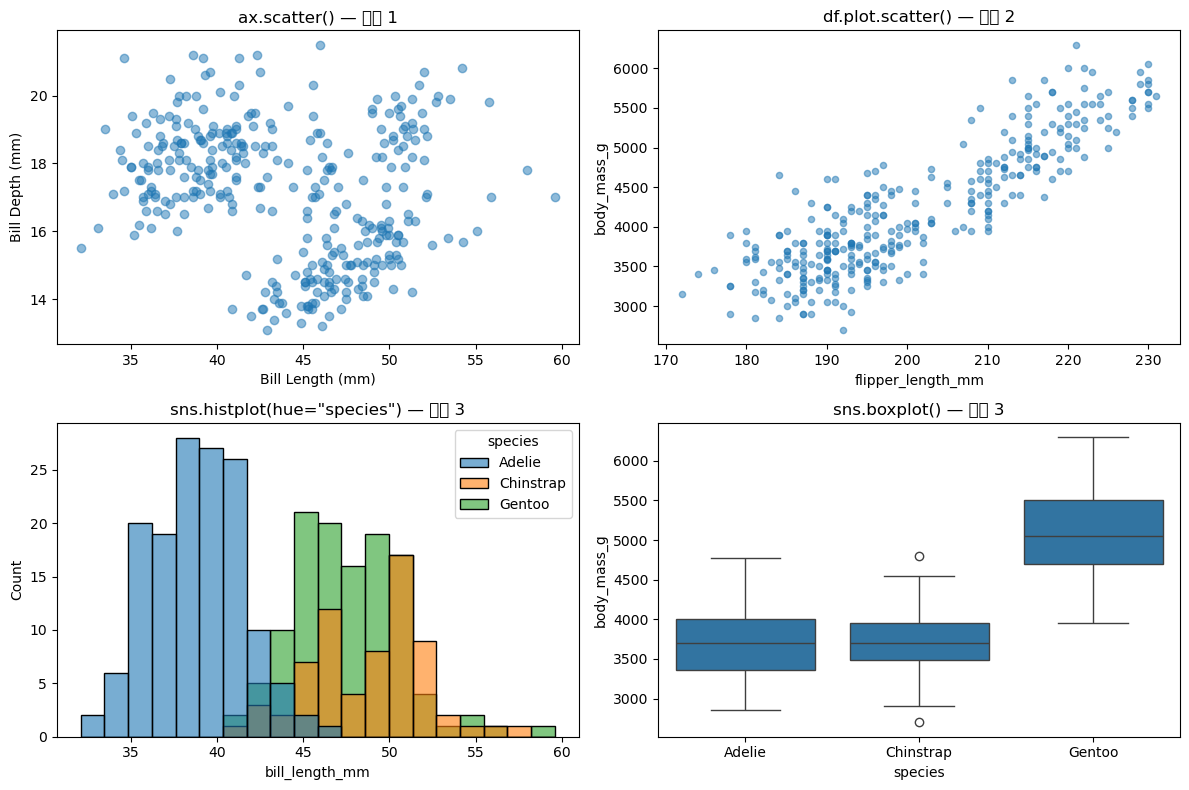

In [273]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (0, 0) 방식 1: 어레이로 직접 산점도
axes[0, 0].scatter(penguins['bill_length_mm'].values,
                   penguins['bill_depth_mm'].values, alpha=0.5)
axes[0, 0].set_xlabel('Bill Length (mm)')
axes[0, 0].set_ylabel('Bill Depth (mm)')
axes[0, 0].set_title('ax.scatter() — 방식 1')

# (0, 1) 방식 2: 데이터프레임 메서드 산점도
penguins.plot.scatter(x='flipper_length_mm', y='body_mass_g',
                      alpha=0.5, ax=axes[0, 1])
axes[0, 1].set_title('df.plot.scatter() — 방식 2')

# (1, 0) 방식 3: 종별 히스토그램
sns.histplot(data=penguins, x='bill_length_mm', hue='species',
             bins=20, alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title('sns.histplot(hue="species") — 방식 3')

# (1, 1) 방식 3: 종별 상자 그림
sns.boxplot(data=penguins, x='species', y='body_mass_g', ax=axes[1, 1])
axes[1, 1].set_title('sns.boxplot() — 방식 3')

plt.tight_layout()
plt.show()

**예제 3: (2, 2) — 같은 그래프 종류를 4개 특성에 반복**

방식 1의 `axes.flat`을 활용한 반복문과 방식 3 axes-level 함수를 결합하면,
수치형 특성 4개의 종별 분포를 한 번에 비교할 수 있다.

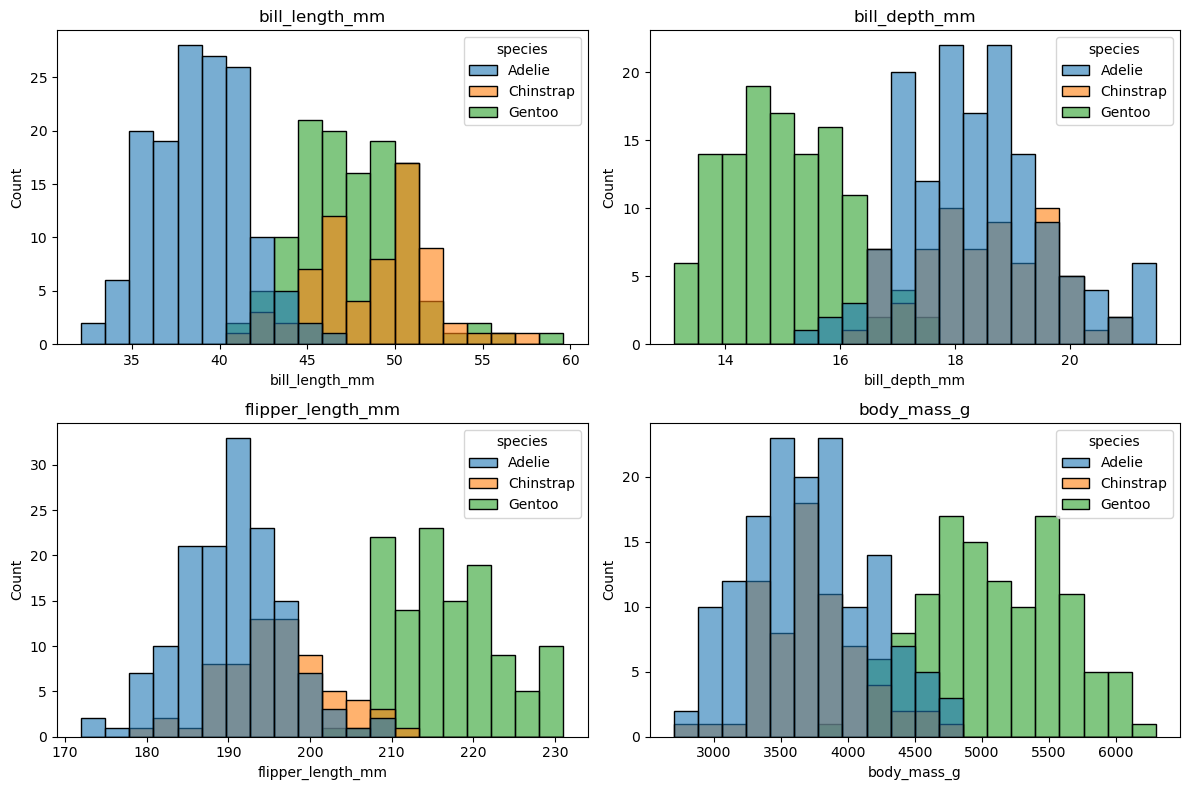

In [274]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

for ax, feat in zip(axes.flat, features):
    sns.histplot(data=penguins, x=feat, hue='species',
                 bins=20, alpha=0.6, ax=ax)
    ax.set_title(feat)

plt.tight_layout()
plt.show()

## 종합: 펭귄 데이터 시각화 대시보드

지금까지 익힌 시각화 기법과 서브플롯 관리를 결합하여,
한 화면에서 펭귄 데이터를 다각도로 살펴보는 대시보드를 만든다.

- 좌상단: 종별 부리 길이 히스토그램
- 우상단: 종별 몸무게 상자 그림
- 좌하단: 날개 길이와 몸무게 산점도(종별 색상)
- 우하단: 부리 길이와 부리 두께 산점도(종별 색상)

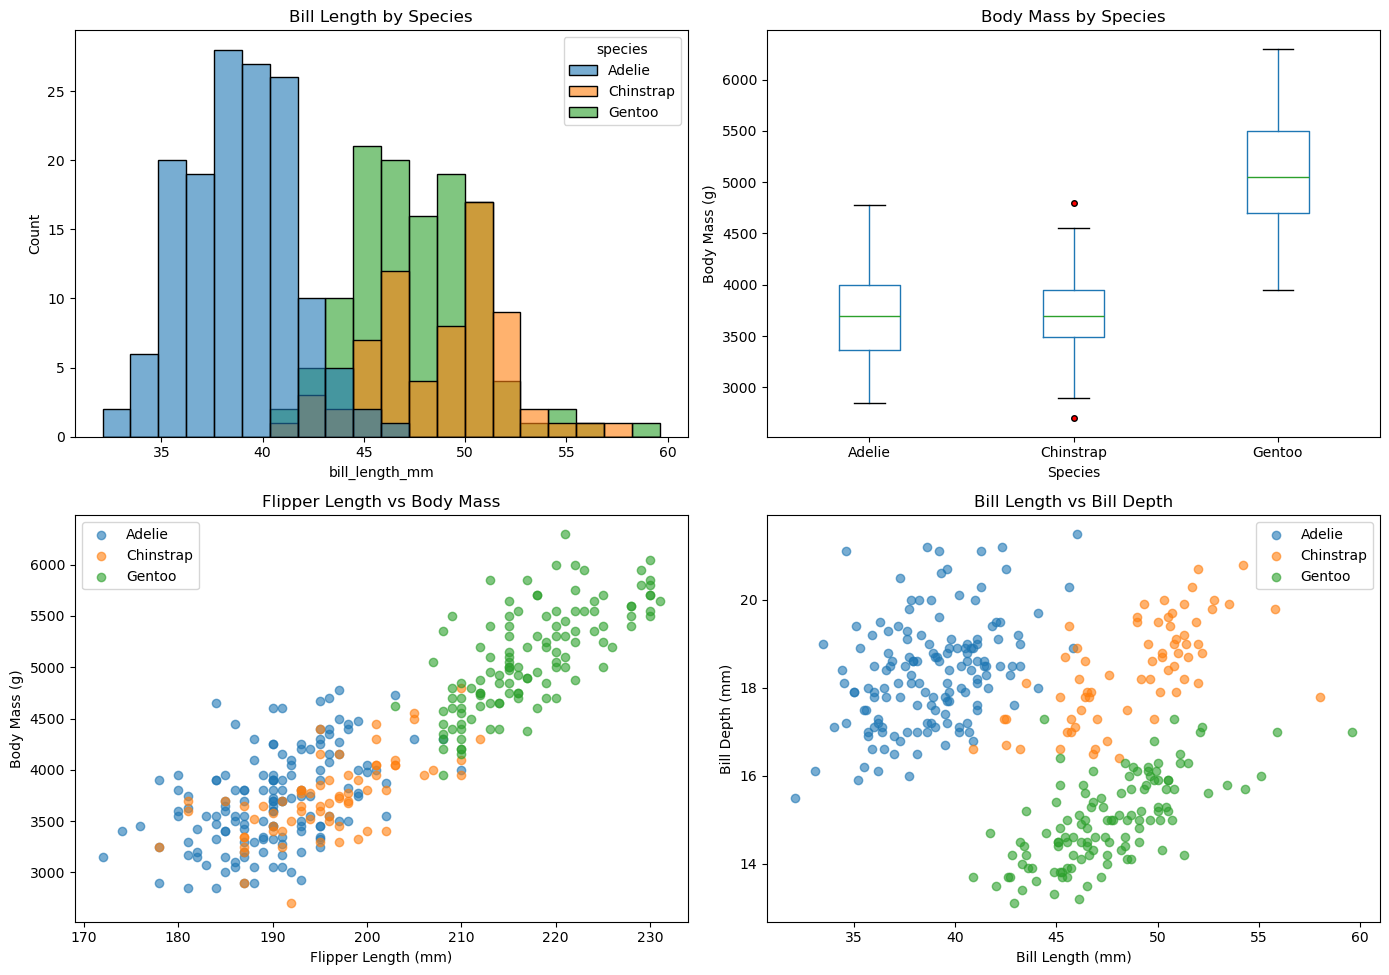

In [275]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 좌상단: 종별 부리 길이 히스토그램
sns.histplot(data=penguins, x='bill_length_mm', hue='species',
             bins=20, alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title('Bill Length by Species')

# 우상단: 종별 몸무게 상자 그림
penguins.boxplot(column='body_mass_g', by='species',
                 grid=False, ax=axes[0, 1],
                 flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
axes[0, 1].set_title('Body Mass by Species')
axes[0, 1].set_xlabel('Species')
axes[0, 1].set_ylabel('Body Mass (g)')

# 좌하단: 날개 길이 vs 몸무게 산점도 (종별 색상)
colors = {'Adelie': 'tab:blue', 'Chinstrap': 'tab:orange', 'Gentoo': 'tab:green'}
for sp, group in penguins.groupby('species'):
    axes[1, 0].scatter(group['flipper_length_mm'], group['body_mass_g'],
                       alpha=0.6, label=sp, color=colors[sp])
axes[1, 0].set_xlabel('Flipper Length (mm)')
axes[1, 0].set_ylabel('Body Mass (g)')
axes[1, 0].set_title('Flipper Length vs Body Mass')
axes[1, 0].legend()

# 우하단: 부리 길이 vs 부리 두께 산점도 (종별 색상)
for sp, group in penguins.groupby('species'):
    axes[1, 1].scatter(group['bill_length_mm'], group['bill_depth_mm'],
                       alpha=0.6, label=sp, color=colors[sp])
axes[1, 1].set_xlabel('Bill Length (mm)')
axes[1, 1].set_ylabel('Bill Depth (mm)')
axes[1, 1].set_title('Bill Length vs Bill Depth')
axes[1, 1].legend()

# boxplot이 자동으로 만든 상위 제목 제거
plt.suptitle('')
plt.tight_layout()
plt.show()

## 연습문제

**문제 1: 단일 시각화**

(1) 펭귄의 몸무게(`body_mass_g`)에 대한 히스토그램을 구간 폭 200g으로 그려라.

힌트: `np.arange(min, max + 200, 200)`로 구간 경계를 만들고 `plt.hist()` 또는 `Series.hist()`에 전달한다.

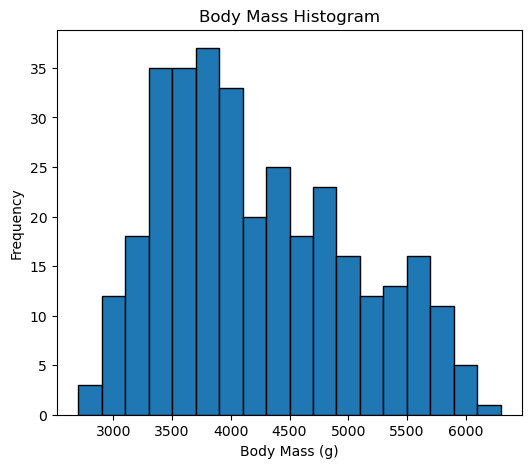

In [276]:
bm = penguins['body_mass_g']
bins = np.arange(bm.min(), bm.max() + 200, 200)

plt.hist(bm, bins=bins, edgecolor='black')
plt.xlabel('Body Mass (g)')
plt.ylabel('Frequency')
plt.title('Body Mass Histogram')
plt.show()

(2) `seaborn`의 `histplot()`을 이용해 성별(`sex`)에 따른 몸무게 분포를 비교하는 히스토그램을 그려라.

힌트: `hue='sex'`를 인자로 사용한다.

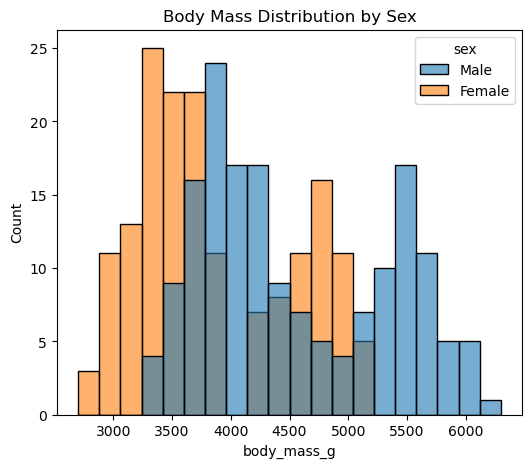

In [277]:
sns.histplot(data=penguins, x='body_mass_g', hue='sex', bins=20, alpha=0.6)
plt.title('Body Mass Distribution by Sex')
plt.show()

(3) 섬(`island`)별로 그룹화한 날개 길이(`flipper_length_mm`)의 상자 그림을 그려라.

힌트: `boxplot()` 메서드에 `by='island'`를 사용한다.

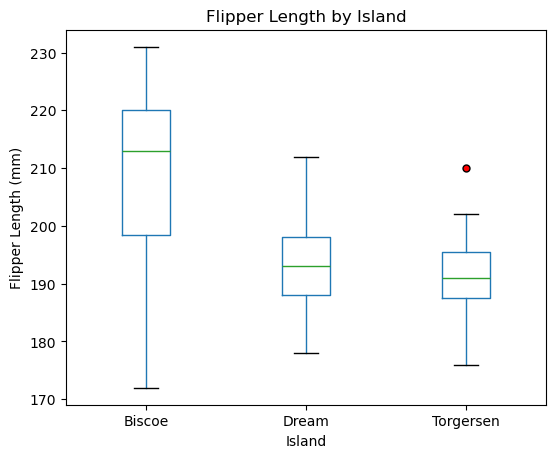

In [278]:
penguins.boxplot(
    column=['flipper_length_mm'],
    by='island',
    grid=False,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5)
)
plt.suptitle('')
plt.title('Flipper Length by Island')
plt.xlabel('Island')
plt.ylabel('Flipper Length (mm)')
plt.show()

**문제 2: 회귀선과 상관관계**

(1) `sns.regplot()`을 이용하여 부리 길이(`bill_length_mm`)와 몸무게(`body_mass_g`)의 산점도와 회귀선을 그려라.

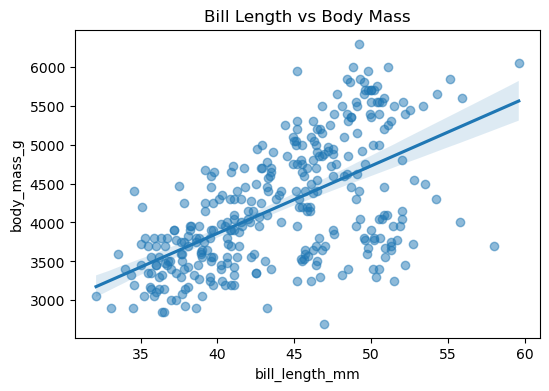

In [279]:
plt.figure(figsize=(6, 4))
sns.regplot(data=penguins, x='bill_length_mm', y='body_mass_g',
            scatter_kws={'alpha': 0.5})
plt.title('Bill Length vs Body Mass')
plt.show()

(2) `sns.lmplot()`을 이용하여 종별로 색상을 달리해 같은 산점도와 회귀선을 그려라.

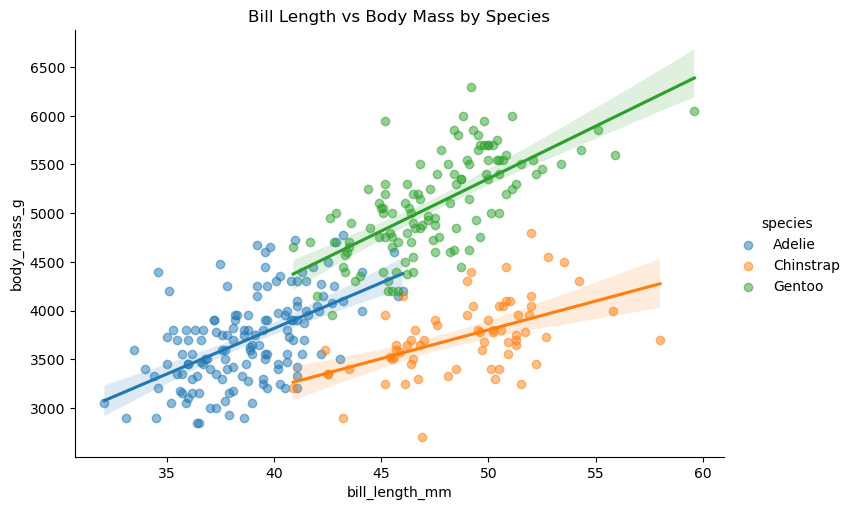

In [280]:
sns.lmplot(data=penguins,
           x='bill_length_mm',
           y='body_mass_g',
           hue='species',
           height=5,
           aspect=1.5,
           scatter_kws={'alpha': 0.5})
plt.title('Bill Length vs Body Mass by Species')
plt.show()

(3) 펭귄 데이터의 수치형 특성에 대한 상관계수 행렬을 위쪽 삼각형을 마스킹한 히트맵으로 그려라.

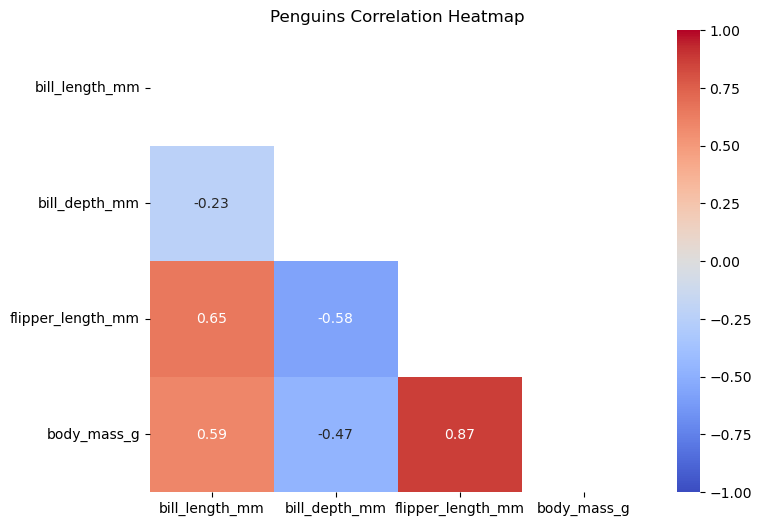

In [281]:
corr_matrix = penguins.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            vmin=-1, vmax=1, mask=mask)
plt.title('Penguins Correlation Heatmap')
plt.show()

**문제 3: 서브플롯 활용**

(1) `Figure`와 `add_subplot()`을 이용해 (1, 2) 모양으로 두 그래프를 좌우 배치하라.

- 왼쪽: `bill_length_mm`의 히스토그램
- 오른쪽: `bill_depth_mm`의 히스토그램

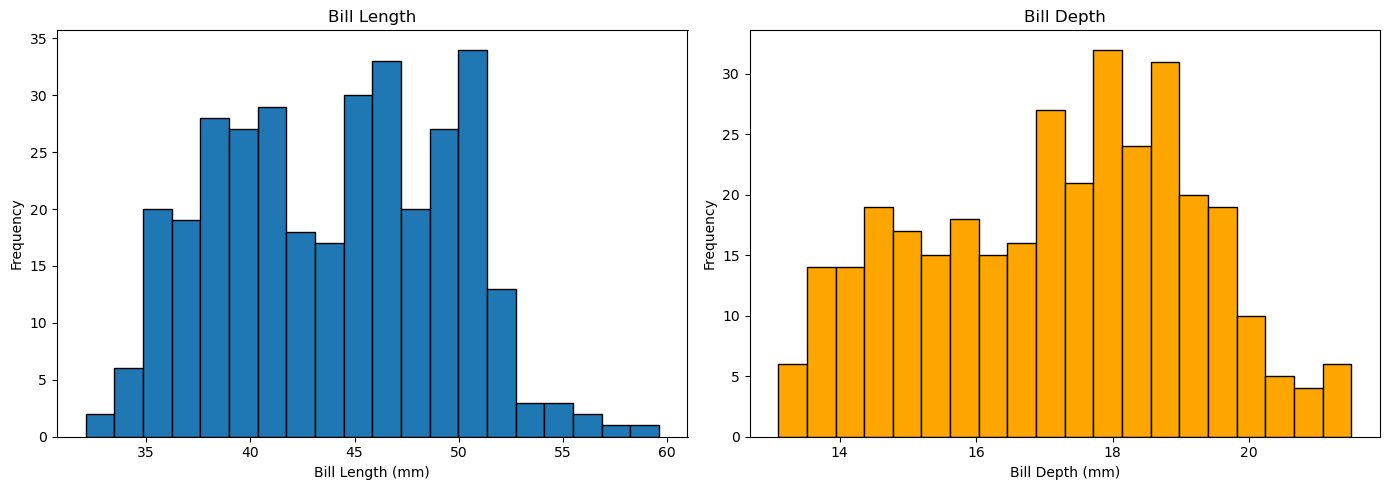

In [282]:
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.hist(penguins['bill_length_mm'], bins=20, edgecolor='black')
ax1.set_xlabel('Bill Length (mm)')
ax1.set_ylabel('Frequency')
ax1.set_title('Bill Length')

ax2 = fig.add_subplot(1, 2, 2)
ax2.hist(penguins['bill_depth_mm'], bins=20, edgecolor='black', color='orange')
ax2.set_xlabel('Bill Depth (mm)')
ax2.set_ylabel('Frequency')
ax2.set_title('Bill Depth')

plt.tight_layout()
plt.show()

(2) `plt.subplots(2, 2)`를 이용하여 네 가지 수치형 특성의 종별 상자 그림을 격자 모양으로 배치하라.

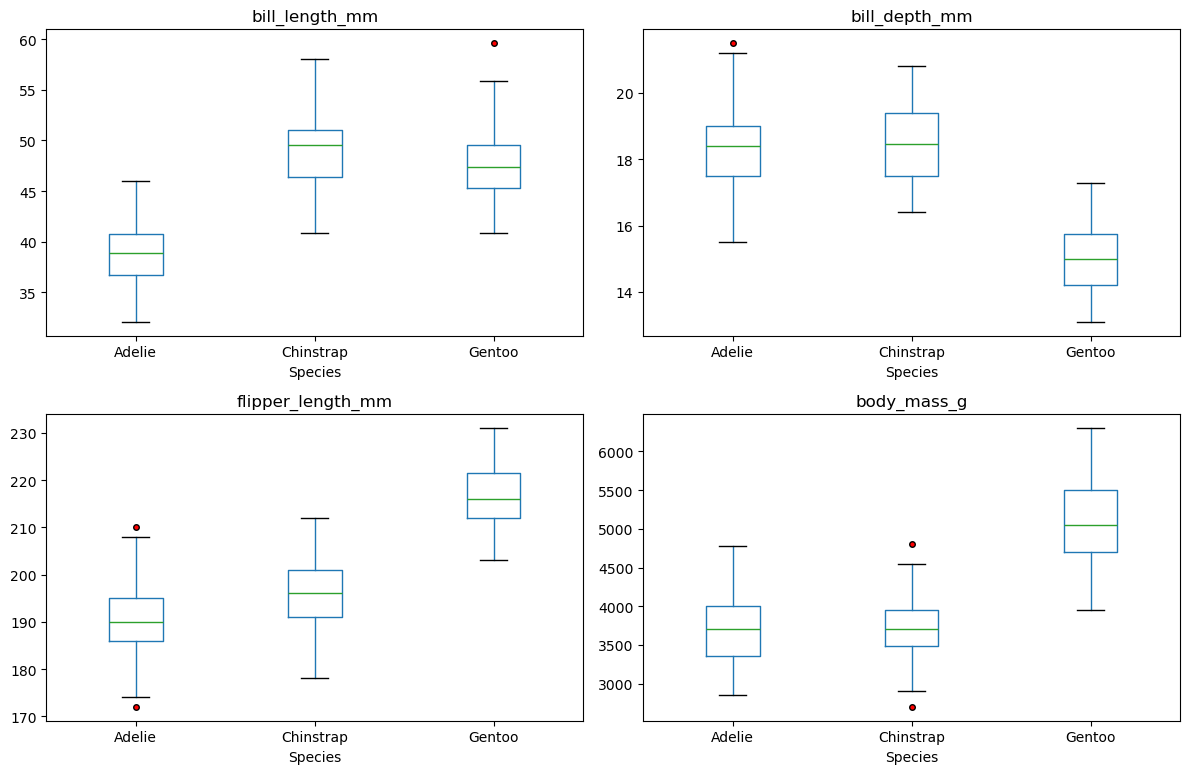

In [283]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

for ax, feat in zip(axes.flat, features):
    penguins.boxplot(column=feat, by='species', grid=False, ax=ax,
                     flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
    ax.set_title(feat)
    ax.set_xlabel('Species')

plt.suptitle('')
plt.tight_layout()
plt.show()